# Прогноз вероятности развития заболевания на основе привычек, показателей здоровья, демографических данных и психологических показателей.

 **Описание проблемы**

---


 Продолжительность и качество жизни человека связано с его здоровьем. Здоровье является важнейшим богатством человека и предупредить болезнь легче, чем ее лечить. Анализ вероятности заболеваний позволяет выявить вероятную болезнь до ее появления.

---
**Цели и задачи:**
Выбрать лучшую модель машинного обучения, предсказывающую вероятность развития заболевания, а также выявить факторы,влияющие на этот процесс.


---

**Описание предоставляемых данных**

Файл: health_lifestyle_classification.csv

Поля:
*  survey_code: соотвествует номеру записа
*  age: возраст
*  bmi: индекс массы тела
*  blood_pressure:систолическое артериальное давление (мм рт. ст.)
*  cholesterol: уровень холестерина (мг/дл)
*  heart_rate: частота сердечных сокращений
*  glucose: уровень глюкозы в крови
*  insulin: уровень инсулина в крови
*  calorie_intake: среднее суточное потребление калорий
*  sugar_intake: суточная норма потребления сахара (в граммах)
*  screen_time: ежедневное время использования устройст
*  stress_level: уровень стресса по самооценке (по шкале от 0 до 10)
*  mental_health_score: оценка психического благополучия по самооценке (по шкале от 0 до 10)
*  training_hours: еженедельные часы тренировок
*  gende:	мужчина / женщина
*  marital_status:	не замужем, замужем, разведена, вдова
*   diet_type: веганство, вегетарианство, всеядность, кето, палео
*   occupation: тип работы или статус трудоустройства
*   sleep_quality: субъективное качество сна
*   mental_health_support: доступ к ресурсам в области психического здоровья
*   exercise_type: тренировки (	Нет, кардио, силовые, смешанные)
*   device_usage: уровень использования устройства
*   healthcare_access: простота доступа к медицинской помощи
*   insurance:есть медицинская страховка или нет
*   family_history: семейный анамнез заболевания
*   sunlight_exposure: ежедневное воздействие солнечного света (низкое/среднее/высокое)
*   pet_owner: есть ли у вас домашние животные (да/нет)
*   caffeine_intake: уровень потребления кофеина
*   meals_per_day: количество приёмов пищи в день
*   physical_activity- физическая активность







In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from tabulate import tabulate
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import shapiro, pearsonr
from scipy.stats import chi2_contingency, pointbiserialr, spearmanr
from scipy.stats import ttest_ind, mannwhitneyu, shapiro, levene
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import joblib

# Настройка визуализации
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# 1. Проведение разведочного анализа данных (EDA)


In [ ]:
df = pd.read_csv('health_lifestyle_classification.csv')

In [ ]:
#Удалим неинформативные столбцы
df=df.drop(['survey_code','bmi','bmi_estimated','family_history','waist_size'],axis=1)

In [ ]:
# Первичный осмотр
print(f"Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
display(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nОсновные описательные статистики для числовых признаков:")
display(df.describe(include=[np.number]))
print("\nОсновные описательные статистики для категориальных признаков:")
display(df.describe(include=['object']))

Размер датасета: (100000, 43)

Первые 5 строк:


,age,gender,height,weight,bmi_scaled,bmi_corrected,blood_pressure,heart_rate,cholesterol,glucose,...,insurance,sunlight_exposure,meals_per_day,caffeine_intake,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,56,Male,173.416872,56.886640,56.747776,18.989117,118.264254,60.749825,214.580523,103.008176,...,No,High,5,Moderate,Yes,0,1.0,5.5,-2.275502,healthy
1,69,Female,163.207380,97.799859,110.148833,36.511417,117.917986,66.463696,115.794002,116.905134,...,No,High,5,High,No,0,1.0,5.5,6.239340,healthy
2,46,Male,177.281966,80.687562,77.019151,25.587429,123.073698,76.043212,138.134787,89.180302,...,Yes,High,4,Moderate,No,0,1.0,5.5,5.423737,healthy
3,32,Female,172.101255,63.142868,63.955440,21.177109,148.173453,68.781981,203.017447,128.375798,...,No,High,1,NaN,Yes,0,1.0,5.5,8.388611,healthy
4,60,Female,163.608816,40.000000,44.829907,14.844299,150.613181,92.335358,200.412439,94.813332,...,Yes,High,1,High,Yes,0,1.0,5.5,0.332622,healthy



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       100000 non-null  int64  
 1   gender                    100000 non-null  object 
 2   height                    100000 non-null  float64
 3   weight                    100000 non-null  float64
 4   bmi_scaled                100000 non-null  float64
 5   bmi_corrected             100000 non-null  float64
 6   blood_pressure            92331 non-null   float64
 7   heart_rate                85997 non-null   float64
 8   cholesterol               100000 non-null  float64
 9   glucose                   100000 non-null  float64
 10  insulin                   84164 non-null   float64
 11  sleep_hours               100000 non-null  float64
 12  sleep_quality             100000 non-null  object 
 13  work_hours             

,age,height,weight,bmi_scaled,bmi_corrected,blood_pressure,heart_rate,cholesterol,glucose,insulin,...,water_intake,screen_time,stress_level,mental_health_score,income,meals_per_day,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,92331.000000,85997.000000,100000.000000,100000.000000,84164.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,91530.000000,100000.000000,100000.0,89526.0,100000.0,100000.000000
mean,48.525990,170.023707,70.064862,73.481627,24.494140,119.980149,74.969177,189.966438,99.994538,14.988258,...,2.006373,6.021525,4.991600,5.004680,4038.127284,2.998720,0.0,1.0,5.5,0.015726
std,17.886768,9.982798,14.693667,17.853206,5.954184,15.015503,9.941668,29.981934,19.982828,5.002783,...,0.688868,2.933835,3.154997,3.164228,1930.025678,1.414786,0.0,0.0,0.0,5.764489
min,18.000000,140.000000,40.000000,29.965484,9.893845,59.128168,34.745092,58.410902,12.434931,-6.794483,...,0.500000,0.000000,0.000000,0.000000,500.000000,1.000000,0.0,1.0,5.5,-9.999895
25%,33.000000,163.306615,59.856938,60.814215,20.271059,109.812060,68.275432,169.667738,86.461401,11.627114,...,1.532011,3.971318,2.000000,2.000000,2665.402843,2.000000,0.0,1.0,5.5,-4.980501
50%,48.000000,170.016778,69.924141,72.470201,24.151699,119.951794,75.046211,190.044579,99.986834,14.983414,...,2.000659,5.991171,5.000000,5.000000,4004.601345,3.000000,0.0,1.0,5.5,0.015589
75%,64.000000,176.728920,80.027418,84.776088,28.247648,130.120621,81.685914,210.222005,113.508722,18.361928,...,2.473047,8.024470,8.000000,8.000000,5360.012694,4.000000,0.0,1.0,5.5,5.008424
max,79.000000,210.000000,139.250894,177.704377,59.142646,184.439195,114.136041,319.875613,183.883548,35.464749,...,5.000000,16.000000,10.000000,10.000000,12029.409353,5.000000,0.0,1.0,5.5,9.999966



Основные описательные статистики для категориальных признаков:


,gender,sleep_quality,alcohol_consumption,smoking_level,mental_health_support,education_level,job_type,occupation,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,caffeine_intake,pet_owner,target
count,100000,100000,57613,100000,100000,100000,100000,100000,100000,75031,100000,100000,100000,100000,66739,100000,100000
unique,2,4,2,3,2,4,6,6,4,3,3,3,2,3,2,2,2
top,Male,Good,Occasionally,Light,No,Bachelor,Labor,Doctor,Vegan,Strength,High,Good,Yes,Low,Moderate,No,healthy
freq,50132,25147,28831,33437,50104,25363,16777,16927,25122,25265,33562,33428,50121,33468,33371,50153,70097


In [ ]:
#Проверим наличие пропусков
df.isna().sum()

,0
age,0
gender,0
height,0
weight,0
bmi_scaled,0
bmi_corrected,0
blood_pressure,7669
heart_rate,14003
cholesterol,0
glucose,0



Анализ целевой переменной (Target)



target
healthy     70097
diseased    29903
Name: count, dtype: int64


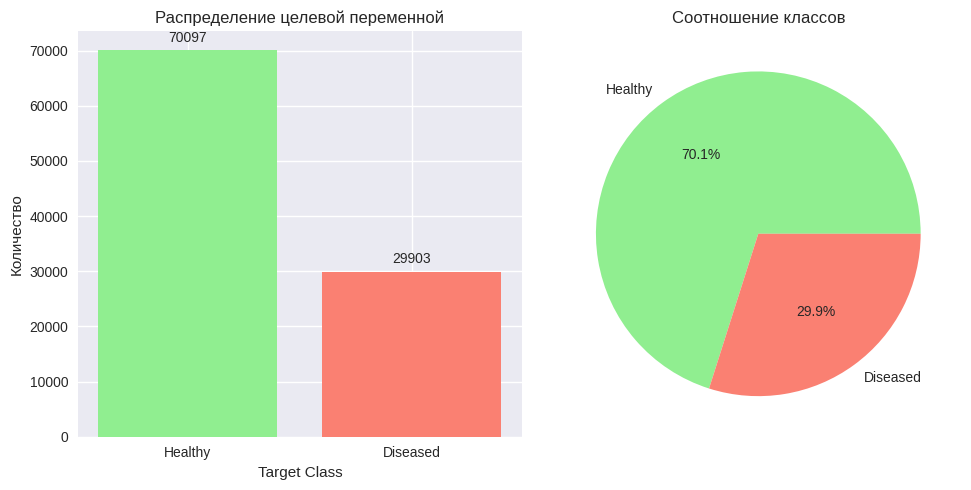

In [ ]:
# Распределение целевой переменной
target_counts = df['target'].value_counts()
print(target_counts)

plt.figure(figsize=(10, 5))

# Столбчатая диаграмма
plt.subplot(1, 2, 1)
bars = plt.bar(target_counts.index, target_counts.values, color=['lightgreen', 'salmon'])
plt.title('Распределение целевой переменной')
plt.xlabel('Target Class')
plt.ylabel('Количество')
plt.xticks(ticks=[0, 1], labels=['Healthy', 'Diseased'])
# Добавляем подписи значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{height}', ha='center', va='bottom')

# Круговая диаграмма
plt.subplot(1, 2, 2)
plt.pie(target_counts.values, labels=['Healthy', 'Diseased'], autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
plt.title('Соотношение классов')

plt.tight_layout()
plt.show()

Визуально видно,что у целевой переменной наблюдается дисбаланс классов (примерно 70%/30%).

**Построим графики для изучения распределения, выбросов и связи с целевой переменной.**

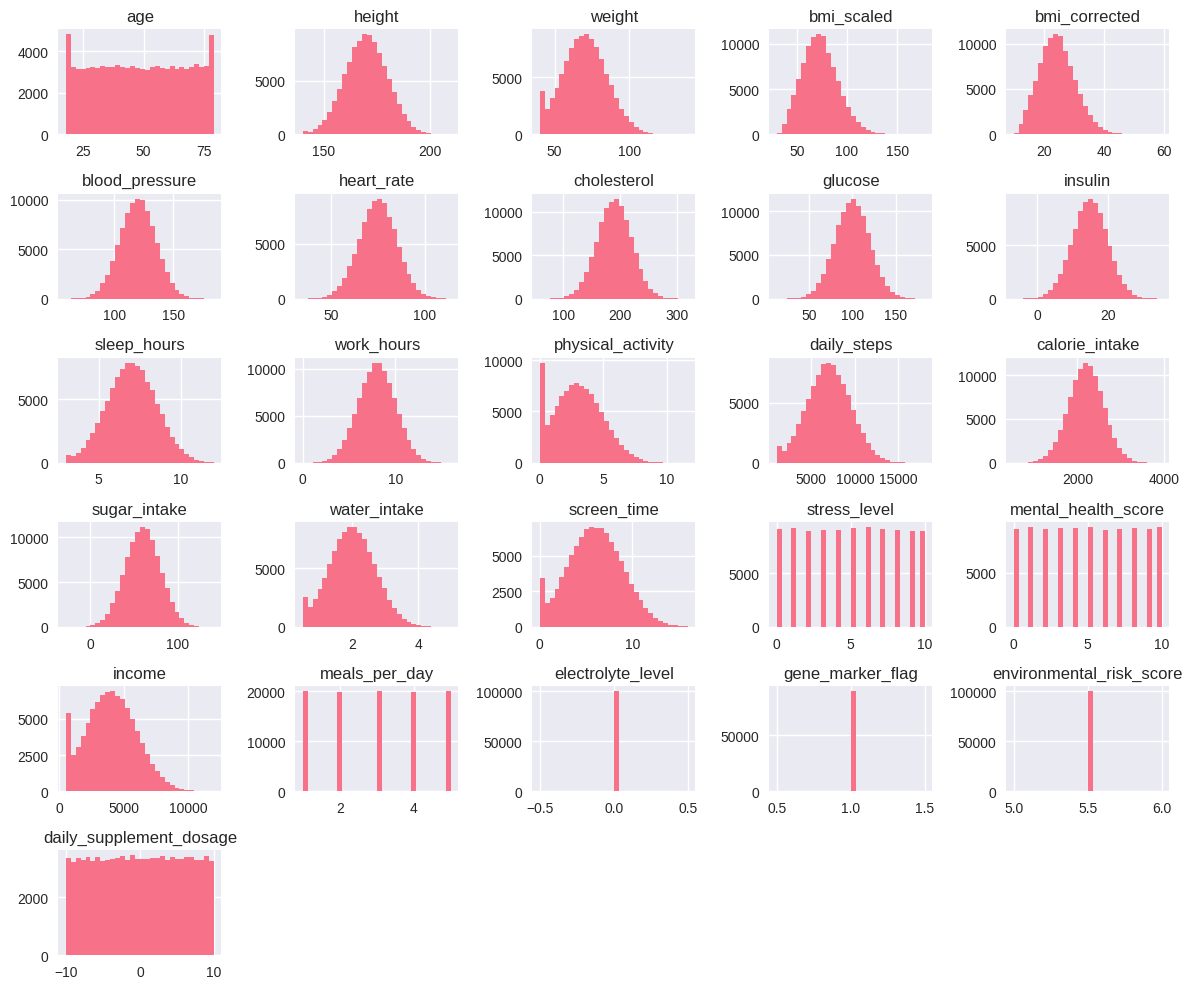

In [ ]:
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

1. Нормально распределённые признаки (колоколообразные, симметричные):

height, blood_pressure, cholesterol, glucose, insulin, sleep hours, work hours, calorie intake, sugar intake, heart_rate  – примерно нормальное распределение.

bmi_scaled, bmi_corrected, daily_steps – тоже напоминают нормальные или слегка смещённые.

2. Смещённые распределения

income  – скошено влево (много людей с низким доходом, мало с высоким).
physical_activity - скошено влево (многo людей вообще не занимаются или очень мало).
weight, physical_activity – распределения несимметричные, ближе к норме, но со смещением.

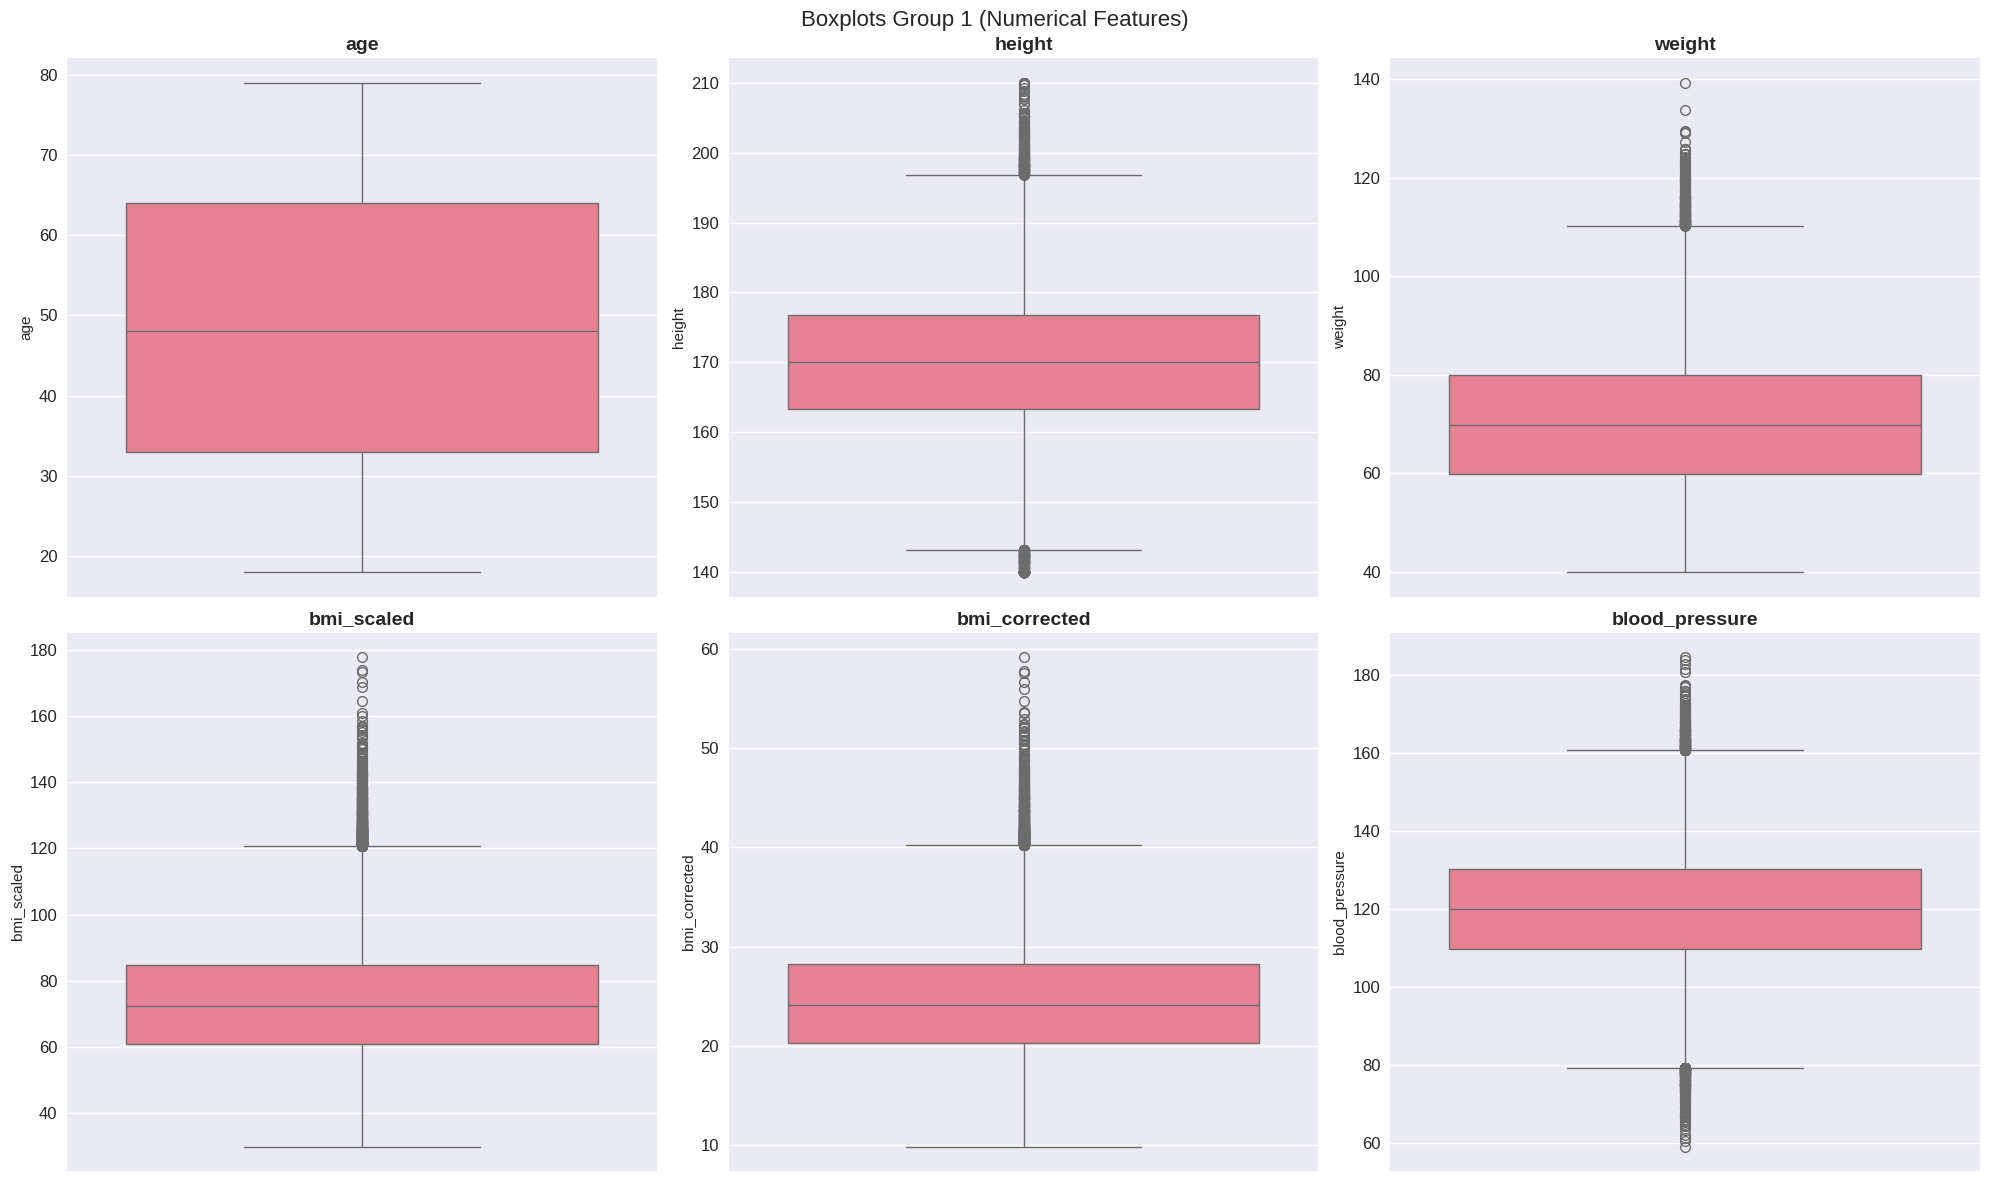

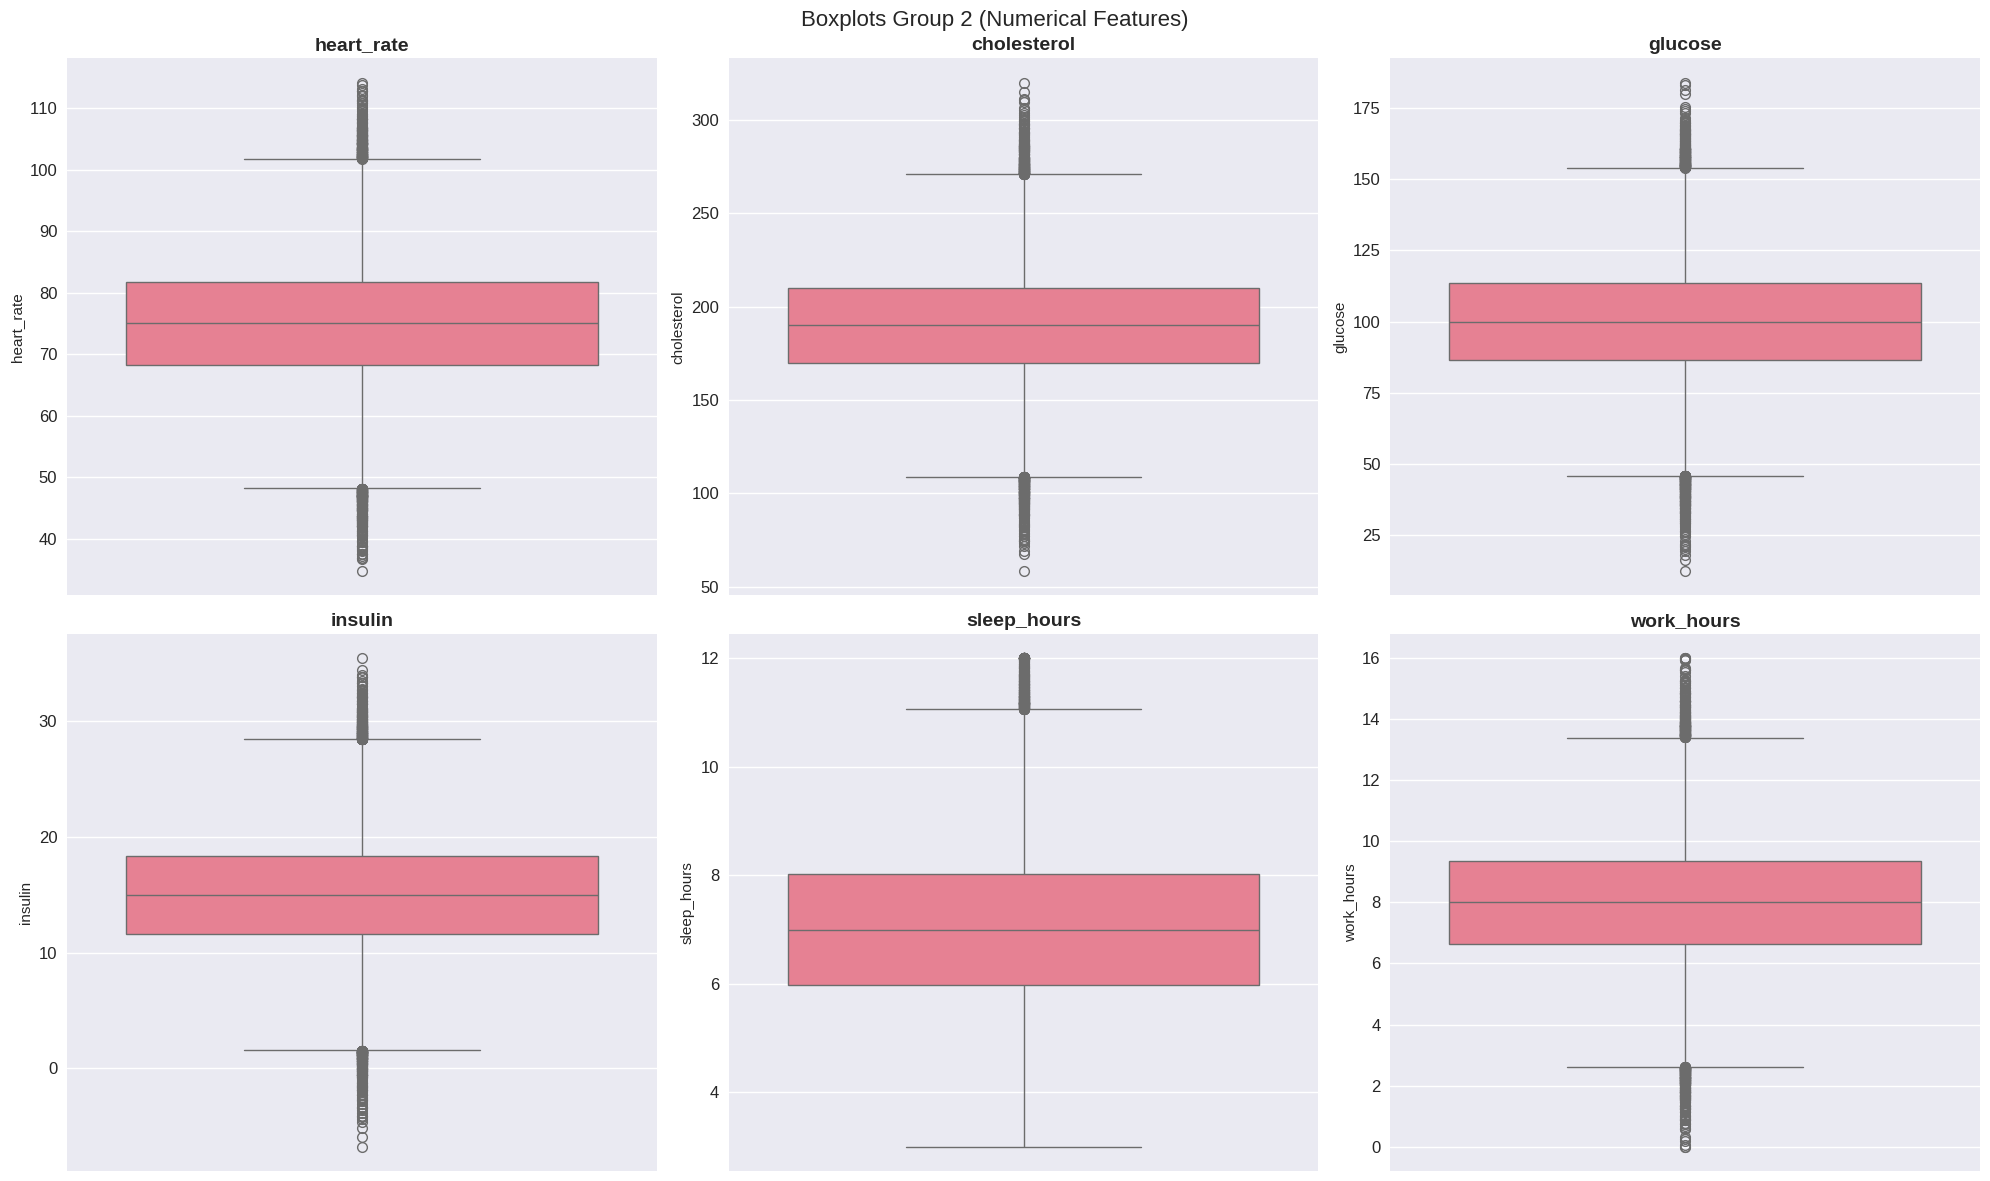

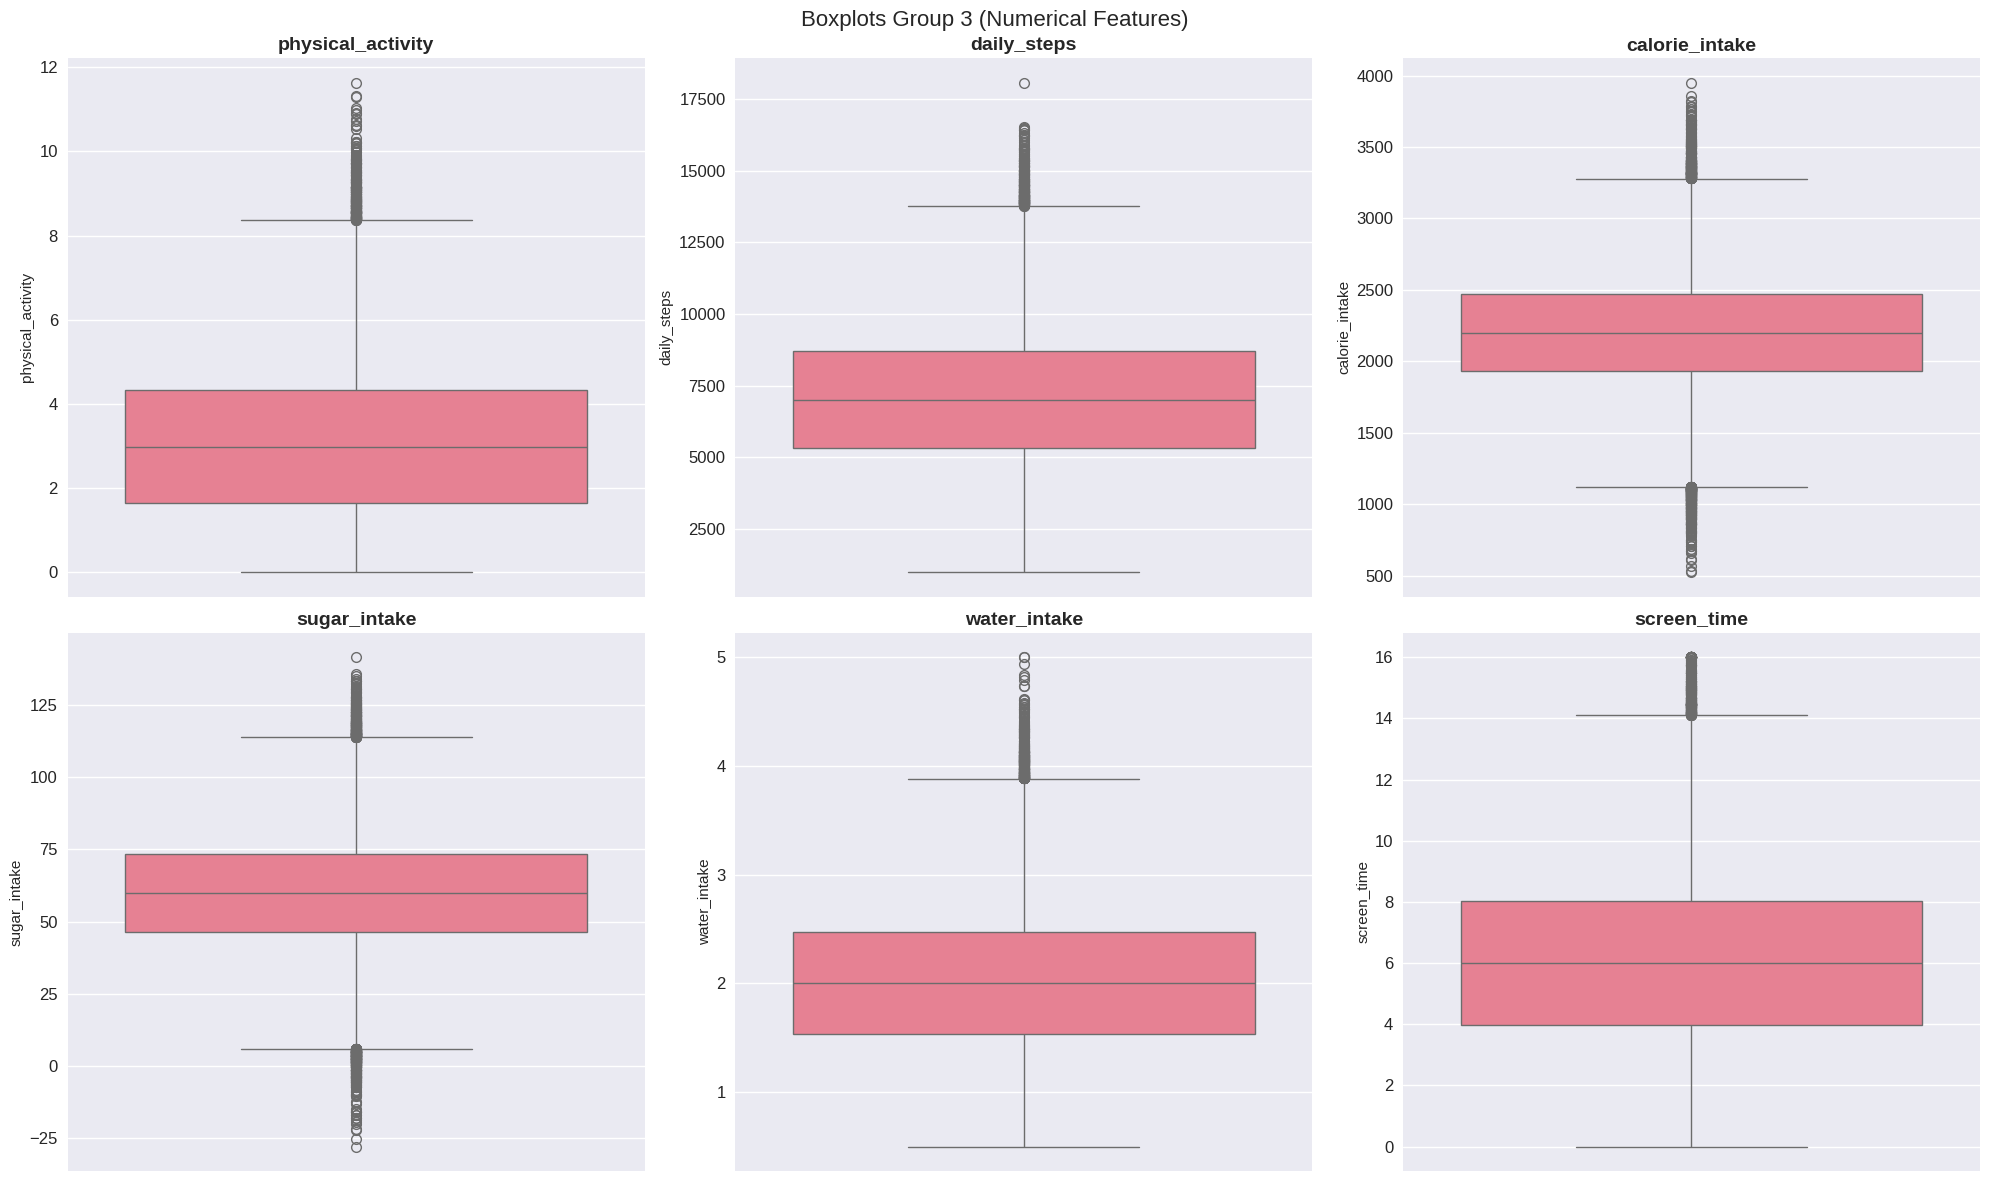

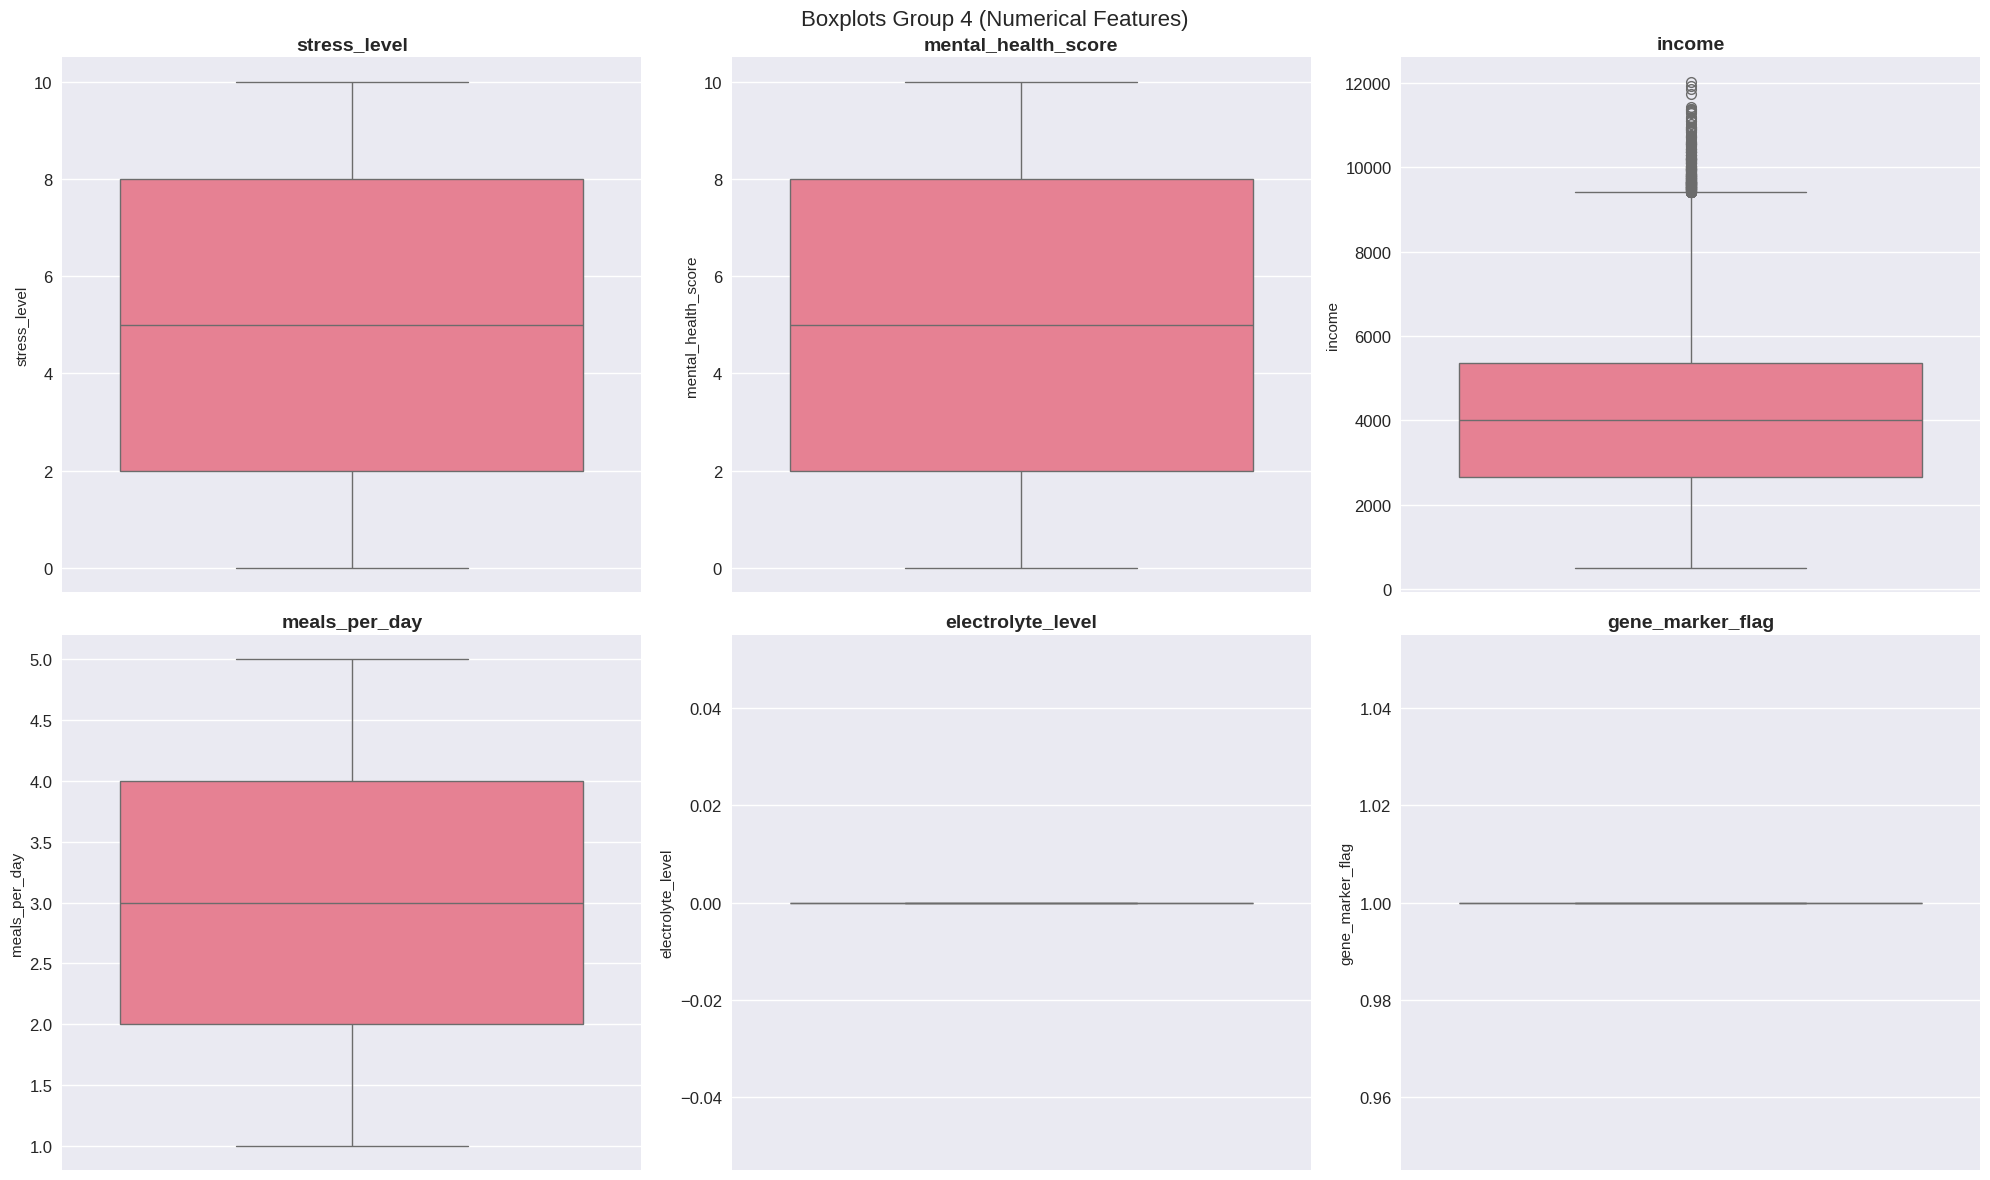

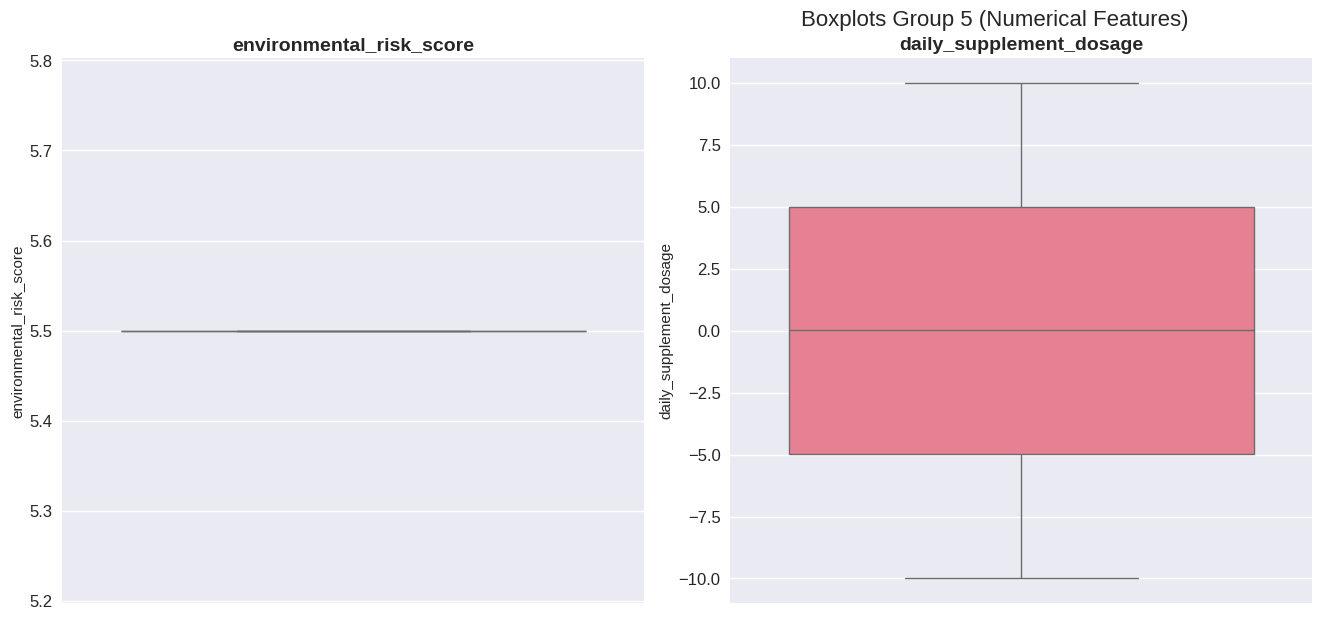

In [ ]:
# Выбираем только числовые столбцы и проверяем наличие выбросов
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

group_size = 6
groups = [numeric_columns[i:i + group_size] for i in range(0, len(numeric_columns), group_size)]

for i, group in enumerate(groups):
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()

    for j, column in enumerate(group):
        sns.boxplot(y=df[column], ax=axes[j])
        axes[j].set_title(column, fontsize=14, fontweight='bold')
        axes[j].tick_params(labelsize=12)


    for k in range(len(group), len(axes)):
        axes[k].set_visible(False)

    plt.suptitle(f'Boxplots Group {i+1} (Numerical Features)', fontsize=16)
    plt.tight_layout()
    plt.show()

16 из 24 признаков имеют выбросы

 **Гистограммы для категориальных признаков**

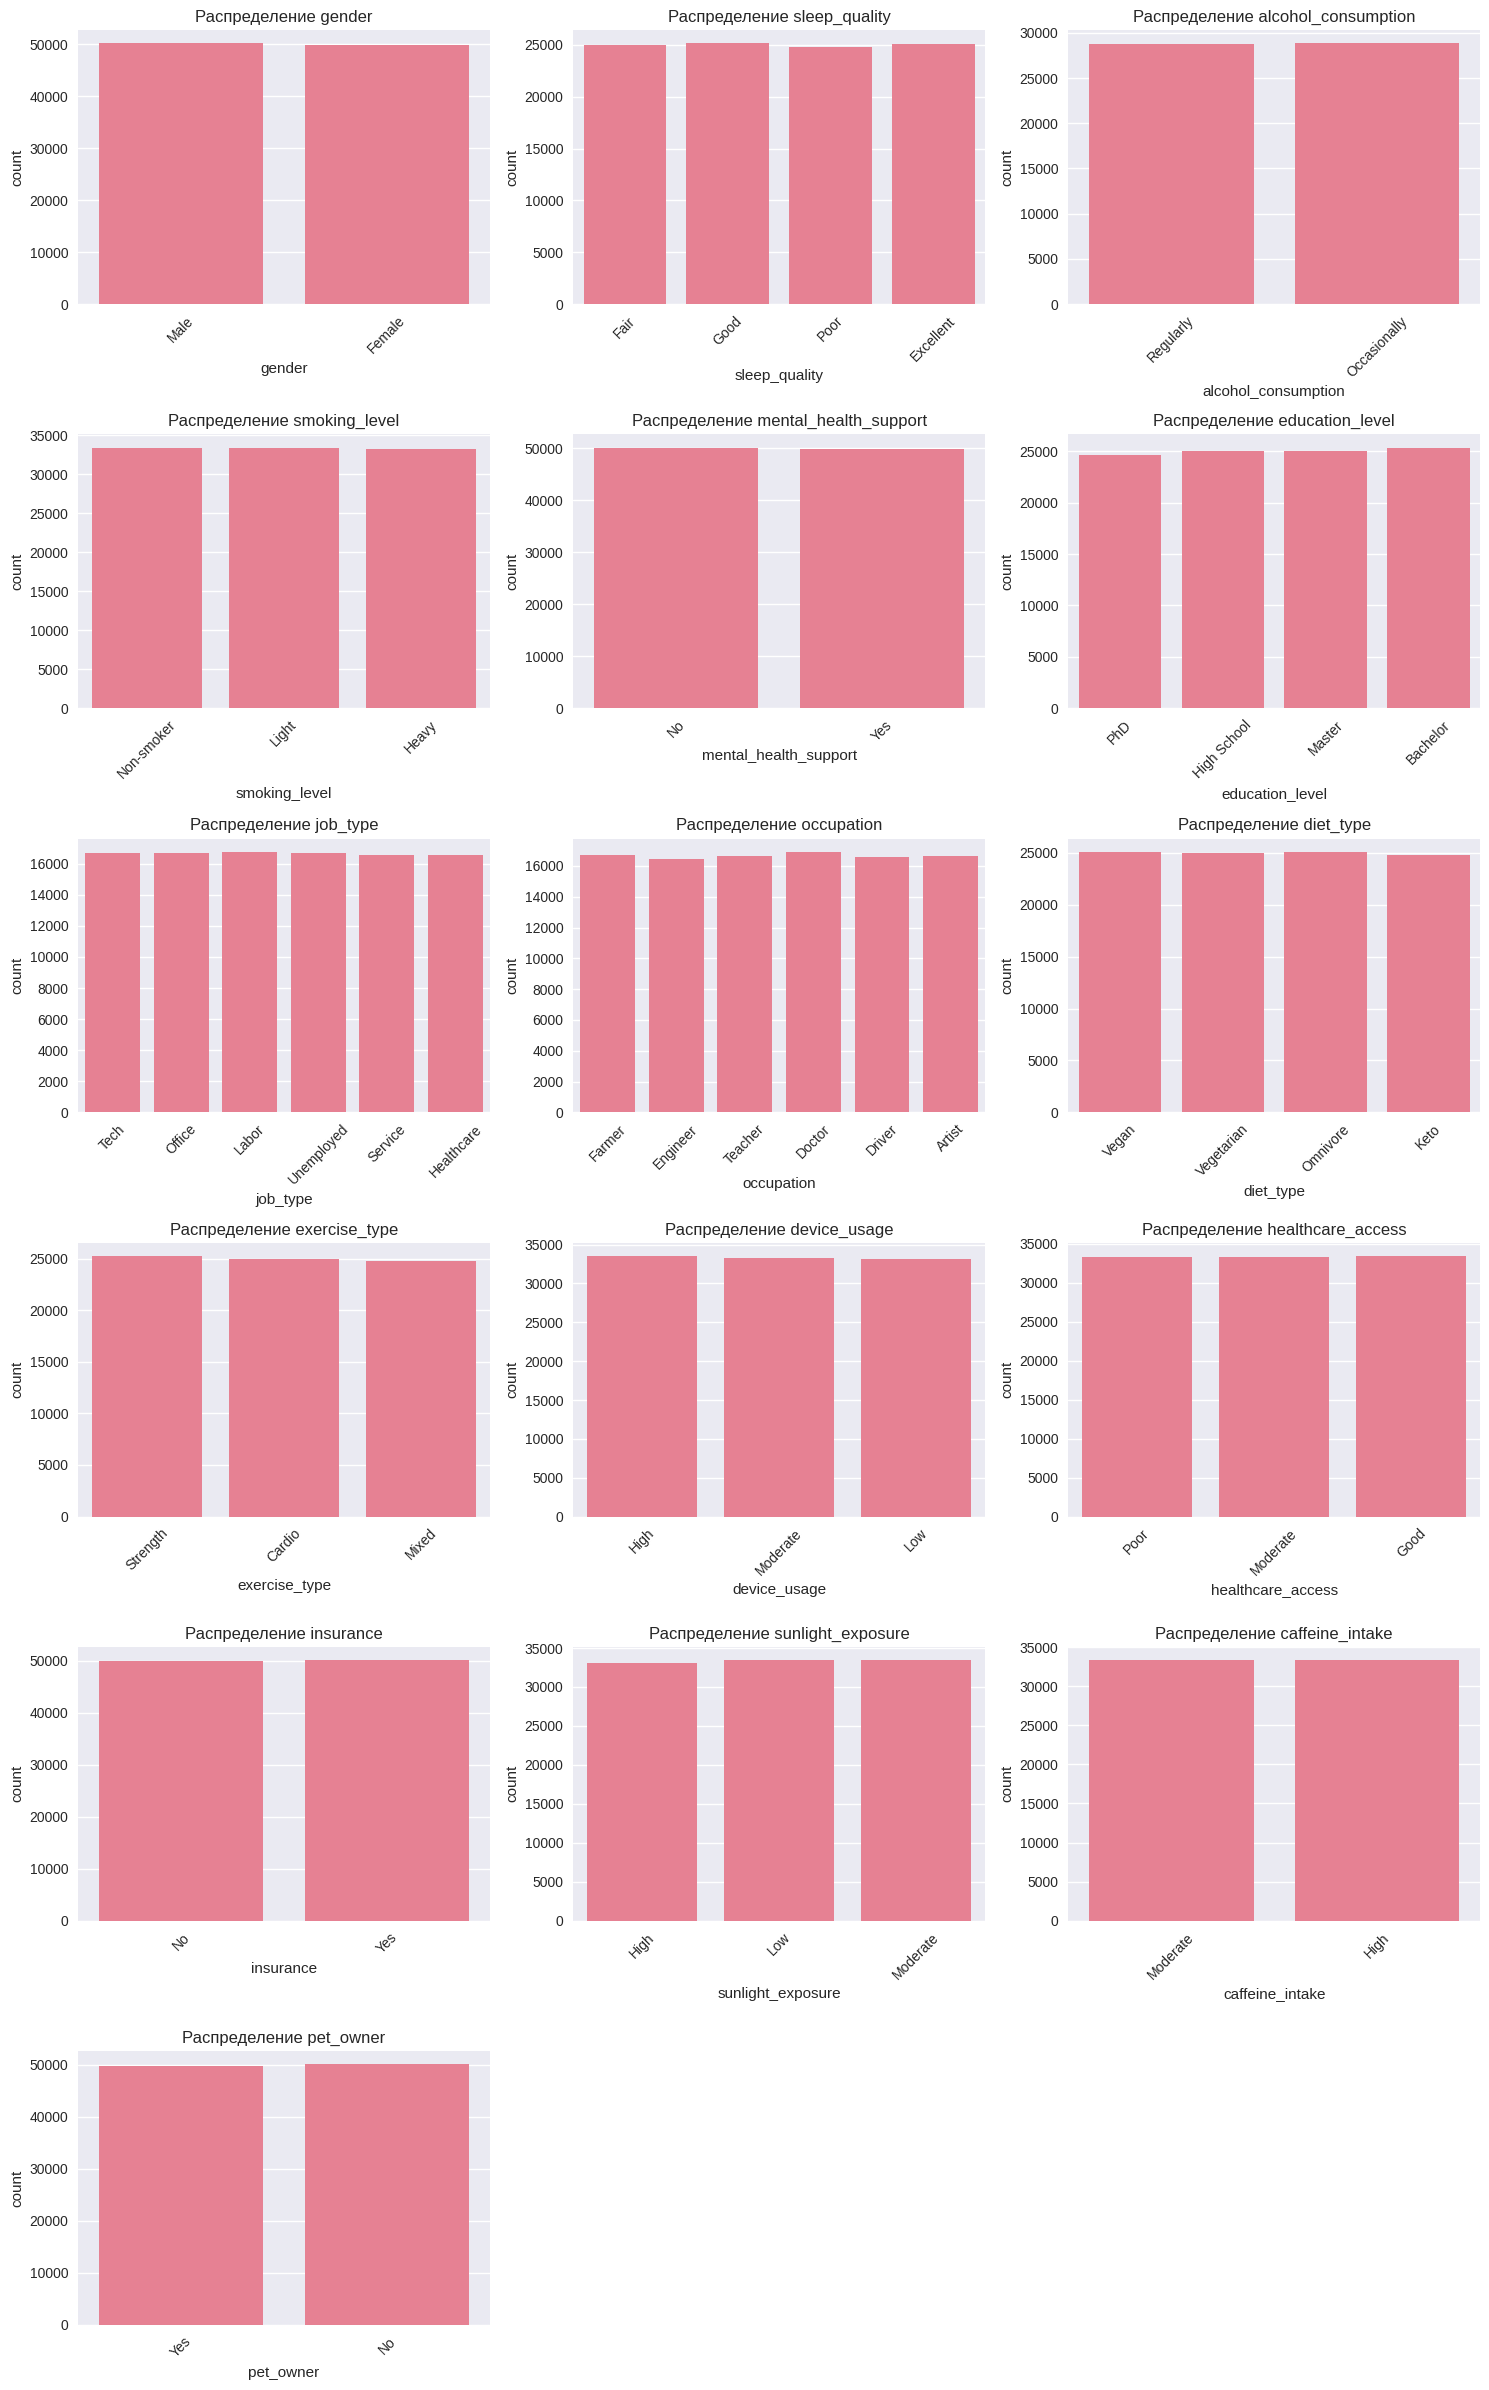

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
target_variable = 'target'
filtered_cols = [col for col in cat_cols if col != 'Surname' and col != target_variable]

# Определяем количество строк для subplot
n_cols = 3
n_rows = (len(filtered_cols) + n_cols - 1) // n_cols  # Округление вверх

# Создаем общую фигуру
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # Преобразуем в плоский массив

# Строим графики
for i, col in enumerate(filtered_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Скрываем пустые subplot
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Данные распределены нормально ,дисбаланса классов нет.

# 2. Предобработка данных

Разделим данные на обучающую и тестовую выборки.

In [ ]:
# Создаем копию DataFrame для предобработки
df_processed = df.copy()

# Уменьшим количество строк в DataFrame
small_df = df_processed.sample(n=1000, random_state=42)

#  Разделение данных на обучающую и тестовую выборки
X = small_df.drop('target', axis=1)
y = small_df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Обработка пропущенных значений

In [ ]:
# Проверяем пропуски в целевой переменной
print("Пропуски в y_train:", y_train.isnull().sum())
print("Пропуски в y_test:", y_test.isnull().sum())

Пропуски в y_train: 0
Пропуски в y_test: 0


In [ ]:
# Проверяем пропуски в X_train
missing_values =X_train.isnull().sum()
missing_percentage = (missing_values / len(X_train)) * 100
missing_report = pd.DataFrame({'Количество пропусков': missing_values, 'Процент': missing_percentage})
missing_report = missing_report[missing_report['Количество пропусков'] > 0].sort_values(by='Процент', ascending=False)

print("Анализ пропущенных значений:")
print(missing_report)


Анализ пропущенных значений:
                     Количество пропусков  Процент
alcohol_consumption                   311   38.875
caffeine_intake                       255   31.875
exercise_type                         199   24.875
insulin                               125   15.625
heart_rate                             96   12.000
gene_marker_flag                       68    8.500
daily_steps                            68    8.500
blood_pressure                         67    8.375
income                                 65    8.125


In [ ]:
# Для числовых признаков: Заполним медианой (устойчива к выбросам)
numeric_features = X_train.select_dtypes(include=[np.number]).columns
numeric_imputer = SimpleImputer(strategy='median')
X_train[numeric_features] = numeric_imputer.fit_transform(X_train[numeric_features])

# Для категориальных признаков: Заполним модой (самым частым значением)
categorical_features = X_train.select_dtypes(include=['object']).columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_features] = categorical_imputer.fit_transform(X_train[categorical_features])

# Проверяем, что пропусков не осталось
print(f"\nПропуски после обработки: {X_train.isnull().sum().sum()}")


Пропуски после обработки: 0


Обработка выбросов

In [ ]:
# Функция для обработки выбросов методом IQR capping
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.clip(lower=lower_bound, upper=upper_bound)

# Применяем ко всем числовым столбцам
X_train[numeric_features] = X_train[numeric_features].apply(cap_outliers_iqr, axis=0)

print("Выбросы обработаны методом IQR capping.")


Выбросы обработаны методом IQR capping.


Обработка категориальных признаков

Применим One-Hot Encoding для номинативных признаков и Label Encoding для порядковых и бинарных.

In [ ]:
ordinal_features = ['sleep_quality', 'device_usage', 'healthcare_access',
                   'sunlight_exposure', 'caffeine_intake', 'alcohol_consumption']

for col in ordinal_features:
    if col in df_processed.columns:
        unique_count = X_train[col].nunique()
        unique_values = X_train[col].unique()
        print(f"{col}:")
        print(f"  Количество уникальных значений: {unique_count}")
        print(f"  Уникальные значения: {sorted(unique_values)}")
        print(f"  Тип данных: {X_train[col].dtype}")
        print("-" * 30)
    else:
        print(f"{col}: столбец не найден в df_processed")
        print("-" * 30)

sleep_quality:
  Количество уникальных значений: 4
  Уникальные значения: ['Excellent', 'Fair', 'Good', 'Poor']
  Тип данных: object
------------------------------
device_usage:
  Количество уникальных значений: 3
  Уникальные значения: ['High', 'Low', 'Moderate']
  Тип данных: object
------------------------------
healthcare_access:
  Количество уникальных значений: 3
  Уникальные значения: ['Good', 'Moderate', 'Poor']
  Тип данных: object
------------------------------
sunlight_exposure:
  Количество уникальных значений: 3
  Уникальные значения: ['High', 'Low', 'Moderate']
  Тип данных: object
------------------------------
caffeine_intake:
  Количество уникальных значений: 2
  Уникальные значения: ['High', 'Moderate']
  Тип данных: object
------------------------------
alcohol_consumption:
  Количество уникальных значений: 2
  Уникальные значения: ['Occasionally', 'Regularly']
  Тип данных: object
------------------------------


Проверяем бинарные признаки


In [ ]:
binary_features = ['gender', 'mental_health_support',
                   'insurance', 'pet_owner']

for col in binary_features:
    if col in X_train.columns:
        unique_count = X_train[col].nunique()
        unique_values = X_train[col].unique()
        print(f"{col}:")
        print(f"  Количество уникальных значений: {unique_count}")
        print(f"  Уникальные значения: {sorted(unique_values)}")
        print(f"  Тип данных: {X_train[col].dtype}")
        print("-" * 30)
    else:
        print(f"{col}: столбец не найден в X_train")
        print("-" * 30)

gender:
  Количество уникальных значений: 2
  Уникальные значения: ['Female', 'Male']
  Тип данных: object
------------------------------
mental_health_support:
  Количество уникальных значений: 2
  Уникальные значения: ['No', 'Yes']
  Тип данных: object
------------------------------
insurance:
  Количество уникальных значений: 2
  Уникальные значения: ['No', 'Yes']
  Тип данных: object
------------------------------
pet_owner:
  Количество уникальных значений: 2
  Уникальные значения: ['No', 'Yes']
  Тип данных: object
------------------------------


In [ ]:
# Кодирование целевой переменной
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)   # кодируем только train
y_test = le_target.transform(y_test)

print("Уникальные значения target до кодирования:", np.unique(df['target']))
print("Уникальные значения target после кодирования:", np.unique(y_train))
print("Соответствие классов:", dict(zip(le_target.classes_, range(len(le_target.classes_)))))


Уникальные значения target до кодирования: ['diseased' 'healthy']
Уникальные значения target после кодирования: [0 1]
Соответствие классов: {'diseased': 0, 'healthy': 1}


In [ ]:
# Вручную определим порядковые признаки и их порядок (на основе EDA)
# Например, 'sleep_quality' может быть порядковой: 'Poor' < 'Fair' < 'Good'
ordinal_mappings = {
    'sleep_quality': ['Poor', 'Fair', 'Good', 'Excellent'],
    'device_usage': ['Low', 'Moderate', 'High'],
    'healthcare_access':['Poor','Moderate','Good'],
    'sunlight_exposure': ['Low', 'Moderate', 'High'],
    'caffeine_intake': ['Moderate', 'High'],
    'alcohol_consumption':['Occasionally', 'Regularly']
}
# Создаем OrdinalEncoder с заданным порядком
ordinal_encoder = OrdinalEncoder(
categories=[ordinal_mappings[col] for col in ordinal_features],
handle_unknown='use_encoded_value', unknown_value=-1
)
# Применяем к тренировочным данным
X_train[ordinal_features] = ordinal_encoder.fit_transform(X_train[ordinal_features])


print("Порядковые признаки закодированы.")
for i, col in enumerate(ordinal_features):
    print(f"  {col}: {ordinal_mappings[col]} -> {list(range(len(ordinal_mappings[col])))}")
print("\n")

Порядковые признаки закодированы.
  sleep_quality: ['Poor', 'Fair', 'Good', 'Excellent'] -> [0, 1, 2, 3]
  device_usage: ['Low', 'Moderate', 'High'] -> [0, 1, 2]
  healthcare_access: ['Poor', 'Moderate', 'Good'] -> [0, 1, 2]
  sunlight_exposure: ['Low', 'Moderate', 'High'] -> [0, 1, 2]
  caffeine_intake: ['Moderate', 'High'] -> [0, 1]
  alcohol_consumption: ['Occasionally', 'Regularly'] -> [0, 1]




Кодирование бинарных признаков

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
for col in binary_features:
    # Обучаем и преобразуем каждый бинарный признак отдельно
    X_train[col] = label_encoder.fit_transform(X_train[col])

Кодирование номинативных признаков с помощью One-Hot Encoding

In [ ]:
# Находим номинативные признаки (все категориальные кроме ordinal и binary)
all_categorical = X_train.select_dtypes(include=['object']).columns.tolist()
nominal_features = [col for col in all_categorical
                   if col not in ordinal_features + binary_features]
print(f"Номинативные признаки для One-Hot: {nominal_features}")


Номинативные признаки для One-Hot: ['smoking_level', 'education_level', 'job_type', 'occupation', 'diet_type', 'exercise_type']


In [ ]:
# Создаем и применяем One-Hot Encoder
onehot_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_onehot = onehot_encoder.fit_transform(X_train[nominal_features])

# Создаем DataFrame с one-hot признаками
onehot_columns = onehot_encoder.get_feature_names_out(nominal_features)
X_train_onehot_df = pd.DataFrame(X_train_onehot, columns=onehot_columns, index=X_train.index)

# Удаляем оригинальные номинативные признаки и добавляем one-hot
X_train_processed = X_train.drop(nominal_features, axis=1)
X_train_processed = pd.concat([X_train_processed, X_train_onehot_df], axis=1)

print("Кодирование завершено!")
print(f"Итоговая размерность: {X_train_processed.shape}")

Кодирование завершено!
Итоговая размерность: (800, 56)


Применяем те же преобразования и для тестовых данных

In [ ]:
# Применяем ВСЕ обученные преобразователи к тестовым данным
X_test[numeric_features] = numeric_imputer.transform(X_test[numeric_features])
X_test[categorical_features] = categorical_imputer.transform(X_test[categorical_features])
X_test[numeric_features] = X_test[numeric_features].apply(cap_outliers_iqr, axis=0)
X_test[ordinal_features] = ordinal_encoder.transform(X_test[ordinal_features])

for col in binary_features:
    # Для бинарных: transform + обработка новых категорий
    X_test[col] = X_test[col].map(lambda x: x if x in label_encoder.classes_ else 'Unknown')
    # Если появилась новая категория 'Unknown', нужно ее обработать
    if 'Unknown' not in label_encoder.classes_:
        # Добавляем 'Unknown' в classes_
        label_encoder.classes_ = np.append(label_encoder.classes_, 'Unknown')
    X_test[col] = label_encoder.transform(X_test[col])

X_test_onehot = onehot_encoder.transform(X_test[nominal_features])
X_test_onehot_df = pd.DataFrame(X_test_onehot, columns=onehot_columns, index=X_test.index)
X_test_processed = X_test.drop(nominal_features, axis=1)
X_test_processed = pd.concat([X_test_processed, X_test_onehot_df], axis=1)

In [ ]:
print("Проверка распределения:")
print("Binary features encoded:")
for col in binary_features:
    print(f"{col}: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

print("\nOrdinal features mapping:")
for i, col in enumerate(ordinal_features):
    print(f"{col}: {dict(zip(ordinal_mappings[col], range(len(ordinal_mappings[col]))))}")

print(f"\nИтоговые признаки: {X_train_processed.shape[1]}")

Проверка распределения:
Binary features encoded:
gender: {'No': 0, 'Yes': 1, 'Unknown': 2}
mental_health_support: {'No': 0, 'Yes': 1, 'Unknown': 2}
insurance: {'No': 0, 'Yes': 1, 'Unknown': 2}
pet_owner: {'No': 0, 'Yes': 1, 'Unknown': 2}

Ordinal features mapping:
sleep_quality: {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
device_usage: {'Low': 0, 'Moderate': 1, 'High': 2}
healthcare_access: {'Poor': 0, 'Moderate': 1, 'Good': 2}
sunlight_exposure: {'Low': 0, 'Moderate': 1, 'High': 2}
caffeine_intake: {'Moderate': 0, 'High': 1}
alcohol_consumption: {'Occasionally': 0, 'Regularly': 1}

Итоговые признаки: 56


In [ ]:
print("\nПервые 5 строк:")
display(X_train_processed.head())


Первые 5 строк:


,age,gender,height,weight,bmi_scaled,bmi_corrected,blood_pressure,heart_rate,cholesterol,glucose,...,occupation_Doctor,occupation_Driver,occupation_Engineer,occupation_Farmer,occupation_Teacher,diet_type_Omnivore,diet_type_Vegan,diet_type_Vegetarian,exercise_type_Mixed,exercise_type_Strength
68413,40.0,1,166.811478,47.940189,51.685549,17.126755,150.033067,87.477359,195.357136,64.361617,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
46368,30.0,1,164.030008,89.473557,99.762964,33.075395,112.034375,71.527116,231.647573,128.772478,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
80595,69.0,0,153.961532,68.926094,87.232932,29.153378,113.060913,79.385691,200.795585,135.306275,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
69228,25.0,1,166.697324,76.660141,82.762502,27.753762,110.806959,61.526105,206.015432,116.707660,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2360,28.0,1,178.493496,50.549644,47.598642,15.602969,139.350074,79.168454,201.147566,98.461122,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


**Отбор признаков и балансировка классов**

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# 1. Отбор признаков на ТРЕНИРОВОЧНЫХ данных
selector = SelectKBest(score_func=mutual_info_classif, k=30)
X_train_selected = selector.fit_transform(X_train_processed, y_train)

# 2. Получаем названия отобранных признаков
selected_features_mask = selector.get_support()
selected_features = X_train_processed.columns[selected_features_mask]

# 3. Создаем DataFrame с отобранными признаками
X_train_selected_df = pd.DataFrame(X_train_selected,
                                  columns=selected_features,
                                  index=X_train_processed.index)

# 4. Применяем тот же отбор к ТЕСТОВЫМ данным
X_test_selected = selector.transform(X_test_processed)
X_test_selected_df = pd.DataFrame(X_test_selected,
                                 columns=selected_features,
                                 index=X_test_processed.index)

print("Отбор признаков завершен!")
print(f"Исходная размерность: {X_train_processed.shape}")
print(f"Размерность после отбора: {X_train_selected_df.shape}")
print(f"\nТоп-30 признаков:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

# 5. Теперь можно делать балансировку классов
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_selected_df, y_train)

print(f"\nПосле балансировки:")
print(f"X_train_bal: {X_train_bal.shape}, y_train_bal: {y_train_bal.shape}")

Отбор признаков завершен!
Исходная размерность: (800, 56)
Размерность после отбора: (800, 30)

Топ-30 признаков:
1. age
2. gender
3. weight
4. bmi_scaled
5. bmi_corrected
6. heart_rate
7. insulin
8. sleep_quality
9. work_hours
10. physical_activity
11. daily_steps
12. sugar_intake
13. screen_time
14. mental_health_score
15. income
16. device_usage
17. insurance
18. sunlight_exposure
19. meals_per_day
20. pet_owner
21. gene_marker_flag
22. environmental_risk_score
23. daily_supplement_dosage
24. smoking_level_Light
25. education_level_High School
26. education_level_Master
27. education_level_PhD
28. occupation_Doctor
29. occupation_Teacher
30. exercise_type_Strength

После балансировки:
X_train_bal: (1088, 30), y_train_bal: (1088,)


# Проверка статистических гипотез

Нулевая гипотеза: Физическая активность  (physical_activity) не влияет на целевую переменную target (здоров или болен).

In [ ]:
    X_train_unbalanced = X_train_selected_df
    y_train_unbalanced = y_train

    # Разделяем данные по группам целевой переменной
    physical_healthy = X_train_unbalanced[y_train_unbalanced == 0]['physical_activity'].dropna()
    physical_sick = X_train_unbalanced[y_train_unbalanced == 1]['physical_activity'].dropna()


       # Проводим t-тест
    t_stat, p_value = ttest_ind(physical_healthy, physical_sick, equal_var=True)

    print(f"\nРезультаты t-теста Стьюдента:")
    print(f"t-статистика: {t_stat:.4f}")
    print(f"p-value: {p_value:.6f}")



    effect_size = cohens_d(physical_healthy, physical_sick)
    print(f"Размер эффекта (Cohen's d): {abs(effect_size):.4f}")

    # Статистический вывод
    alpha = 0.05
    print(f"\nСтатистический вывод (α={alpha}):")
    if p_value < alpha:
        print("ОТКЛОНЯЕМ нулевую гипотезу")
        print(f"Физическая активность СТАТИСТИЧЕСКИ ЗНАЧИМО влияет на целевую переменную")
    else:
        print("НЕ ОТКЛОНЯЕМ нулевую гипотезу")
        print("Нет доказательств влияния физической активности на целевую переменную")
        print(f"p-value ({p_value:.4f}) ≥ α ({alpha})")




Результаты t-теста Стьюдента:
t-статистика: -2.3563
p-value: 0.018697
Размер эффекта (Cohen's d): 0.1786

Статистический вывод (α=0.05):
ОТКЛОНЯЕМ нулевую гипотезу
Физическая активность СТАТИСТИЧЕСКИ ЗНАЧИМО влияет на целевую переменную


Нулевая гипотеза: Потребление сахара не влияет на целевую переменную.

In [ ]:
# Разделяем потребление сахара по группам целевой переменной
sugar_healthy = X_train_processed[y_train == 0]['sugar_intake'].dropna()
sugar_sick = X_train_processed[y_train == 1]['sugar_intake'].dropna()

#  Проверка нормальности распределения
shapiro_healthy = shapiro(sugar_healthy)
shapiro_sick = shapiro(sugar_sick)

print("\nПроверка условий для t-теста:")
print(f"Нормальность распределения (здоровые): p = {shapiro_healthy.pvalue:.4f}")
print(f"Нормальность распределения (больные): p = {shapiro_sick.pvalue:.4f}")

# Проводим независимый t-тест
t_stat, p_value = ttest_ind(sugar_healthy, sugar_sick, equal_var=True)

print(f"\nРезультаты t-теста Стьюдента:")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

# Проверяем статистическую значимость
alpha = 0.05
if p_value < alpha:
    print(f"\n✅ ОТКЛОНЯЕМ нулевую гипотезу (p < {alpha})")
    print("Потребление сахара СТАТИСТИЧЕСКИ ЗНАЧИМО влияет на целевую переменную")
else:
    print(f"\n✅ НЕ ОТКЛОНЯЕМ нулевую гипотезу (p ≥ {alpha})")
    print("Нет доказательств влияния потребления сахара на целевую переменную")



Проверка условий для t-теста:
Нормальность распределения (здоровые): p = 0.3423
Нормальность распределения (больные): p = 0.4731

Результаты t-теста Стьюдента:
t-статистика: 1.0469
p-value: 0.295470

✅ НЕ ОТКЛОНЯЕМ нулевую гипотезу (p ≥ 0.05)
Нет доказательств влияния потребления сахара на целевую переменную


# Построение моделей машинного обучения

In [ ]:
# МАСШТАБИРОВАНИЕ ДАННЫХ
scaler = StandardScaler()

# Масштабируем обучающие данные
X_train_scaled = scaler.fit_transform(X_train_bal)

# Масштабируем тестовые данные (используя параметры с train)
X_test_scaled = scaler.transform(X_test_selected_df)


Логистическая регрессия

In [ ]:
# Создаем и обучаем модель логистической регрессии
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

# Обучаем модель на масштабированных данных
log_reg.fit(X_train_scaled, y_train_bal)

# Делаем предсказания на масштабированных тестовых данных
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Вычисляем все метрики
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Оцениваем качество модели
print("=" * 50)
print("ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ - РЕЗУЛЬТАТЫ")
print("=" * 50)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\n")


ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ - РЕЗУЛЬТАТЫ
Accuracy: 0.5350
Precision: 0.5407
Recall: 0.5350
F1-score: 0.5377




Метод KNN

In [ ]:
# Создаем и обучаем модель KNN
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    algorithm='auto',
    p=2
)

# Обучаем модель на масштабированных данных
knn.fit(X_train_scaled, y_train_bal)

# Делаем предсказания на масштабированных тестовых данных
y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1] if len(le_target.classes_) == 2 else None

# Вычисляем все метрики
accuracy_knn = accuracy_score(y_test, y_pred)
precision_knn = precision_score(y_test, y_pred, average='weighted')
recall_knn = recall_score(y_test, y_pred, average='weighted')
f1_knn = f1_score(y_test, y_pred, average='weighted')

# Оцениваем качество модели
print("=" * 50)
print("K-NEAREST NEIGHBORS (KNN) - РЕЗУЛЬТАТЫ")
print("=" * 50)

print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")
print("\n")

K-NEAREST NEIGHBORS (KNN) - РЕЗУЛЬТАТЫ
Accuracy: 0.3600
Precision: 0.4648
Recall: 0.3600
F1-score: 0.3622




Дерево решений

In [ ]:
# Создаем и обучаем модель дерева решений
dtree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,  # ограничиваем глубину для избежания переобучения
    min_samples_split=10,  # минимальное количество samples для разделения
    min_samples_leaf=5,  # минимальное количество samples в листе
    class_weight='balanced'  # учитываем дисбаланс классов
)

# Обучаем модель
dtree.fit(X_train_bal, y_train_bal)

# Делаем предсказания
y_pred = dtree.predict(X_test_selected_df)
y_pred_proba = dtree.predict_proba(X_test_selected_df)[:, 1] if len(le_target.classes_) == 2 else None

# Вычисляем все метрики
accuracy_dt = accuracy_score(y_test, y_pred)
precision_dt = precision_score(y_test, y_pred, average='weighted')
recall_dt = recall_score(y_test, y_pred, average='weighted')
f1_dt = f1_score(y_test, y_pred, average='weighted')

# Оцениваем качество модели
print("=" * 50)
print("ДЕРЕВО РЕШЕНИЙ - РЕЗУЛЬТАТЫ")
print("=" * 50)

print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print("\n")

ДЕРЕВО РЕШЕНИЙ - РЕЗУЛЬТАТЫ
Accuracy: 0.5350
Precision: 0.5119
Recall: 0.5350
F1-score: 0.5222




Random forest

In [ ]:
# Создаем и обучаем модель Random Forest
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100,  # количество деревьев
    max_depth=10,  # максимальная глубина деревьев
    min_samples_split=5,  # минимальное количество samples для разделения
    min_samples_leaf=2,  # минимальное количество samples в листе
    class_weight='balanced',  # учитываем дисбаланс классов
    n_jobs=-1  # используем все ядра процессора
)

# Обучаем модель
rf.fit(X_train_bal, y_train_bal)

# Делаем предсказания
y_pred = rf.predict(X_test_selected_df)
y_pred_proba = rf.predict_proba(X_test_selected_df)[:, 1] if len(le_target.classes_) == 2 else None

# Вычисляем все метрики
accuracy_rf = accuracy_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred, average='weighted')
recall_rf = recall_score(y_test, y_pred, average='weighted')
f1_rf = f1_score(y_test, y_pred, average='weighted')

# Оцениваем качество модели
print("=" * 50)
print("RANDOM FOREST - РЕЗУЛЬТАТЫ")
print("=" * 50)

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print("\n")

RANDOM FOREST - РЕЗУЛЬТАТЫ
Accuracy: 0.6350
Precision: 0.5198
Recall: 0.6350
F1-score: 0.5497




Градиентный бустинг (XGBoost)

In [ ]:
# Создаем и обучаем модель XGBoost
xgb = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

# Обучаем модель
xgb.fit(X_train_bal, y_train_bal)

# Делаем предсказания
y_pred = xgb.predict(X_test_selected_df)
y_pred_proba = xgb.predict_proba(X_test_selected_df)[:, 1] if len(le_target.classes_) == 2 else None

# Вычисляем все метрики
accuracy_gb = accuracy_score(y_test, y_pred)
precision_gb = precision_score(y_test, y_pred, average='weighted')
recall_gb = recall_score(y_test, y_pred, average='weighted')
f1_gb = f1_score(y_test, y_pred, average='weighted')

# Оцениваем качество модели
print("=" * 50)
print("XGBOOST - РЕЗУЛЬТАТЫ")
print("=" * 50)

print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1-score: {f1_gb:.4f}")
print("\n")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:41:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBOOST - РЕЗУЛЬТАТЫ
Accuracy: 0.6050
Precision: 0.4808
Recall: 0.6050
F1-score: 0.5260




# Сравнение моделей

In [ ]:
# Создаем сводную таблицу с метриками всех моделей
metrics_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [accuracy, accuracy_knn, accuracy_dt, accuracy_rf, accuracy_gb],
    'Precision': [precision, precision_knn, precision_dt, precision_rf, precision_gb],
    'Recall': [recall, recall_knn, recall_dt, recall_rf, recall_gb],
    'F1-Score': [f1, f1_knn, f1_dt, f1_rf, f1_gb]
})

# Сортируем по F1-Score (обычно лучший агрегированный показатель)
metrics_summary_sorted = metrics_summary.sort_values('F1-Score', ascending=False)

# Выводим красивую таблицу
print("=" * 80)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК ВСЕХ МОДЕЛЕЙ")
print("=" * 80)
print(tabulate(metrics_summary_sorted.round(4), headers='keys', tablefmt='grid', showindex=False))
print("\n")

# Находим лучшую модель по F1-Score
best_model_f1 = metrics_summary_sorted.iloc[0]
best_model_name = best_model_f1['Model']
best_f1_score = best_model_f1['F1-Score']

print("=" * 50)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ")
print("=" * 50)
print(f" ЛУЧШАЯ МОДЕЛЬ ПО F1-SCORE: {best_model_name}")
print(f"   F1-Score: {best_f1_score:.4f}")
print(f"   Accuracy: {best_model_f1['Accuracy']:.4f}")
print(f"   Precision: {best_model_f1['Precision']:.4f}")
print(f"   Recall: {best_model_f1['Recall']:.4f}")

# Анализ по разным метрикам
best_by_accuracy = metrics_summary.loc[metrics_summary['Accuracy'].idxmax()]
best_by_precision = metrics_summary.loc[metrics_summary['Precision'].idxmax()]
best_by_recall = metrics_summary.loc[metrics_summary['Recall'].idxmax()]

print(f"\n Лучшая по Accuracy: {best_by_accuracy['Model']} ({best_by_accuracy['Accuracy']:.4f})")
print(f" Лучшая по Precision: {best_by_precision['Model']} ({best_by_precision['Precision']:.4f})")
print(f" Лучшая по Recall: {best_by_recall['Model']} ({best_by_recall['Recall']:.4f})")

СВОДНАЯ ТАБЛИЦА МЕТРИК ВСЕХ МОДЕЛЕЙ
+---------------------+------------+-------------+----------+------------+
| Model               |   Accuracy |   Precision |   Recall |   F1-Score |
+=====================+============+=============+==========+============+
| Random Forest       |      0.635 |      0.5198 |    0.635 |     0.5497 |
+---------------------+------------+-------------+----------+------------+
| Gradient Boosting   |      0.605 |      0.4808 |    0.605 |     0.526  |
+---------------------+------------+-------------+----------+------------+
| Logistic Regression |      0.535 |      0.5119 |    0.535 |     0.5222 |
+---------------------+------------+-------------+----------+------------+
| Decision Tree       |      0.535 |      0.5119 |    0.535 |     0.5222 |
+---------------------+------------+-------------+----------+------------+
| K-Nearest Neighbors |      0.36  |      0.4648 |    0.36  |     0.3622 |
+---------------------+------------+-------------+----------+---

На основе полученных метрик можно сделать следующие выводы:Random Forest показал лучшие результаты с accuracy 63% (остальные параметры также лучше,чем у других моделей). Gradient Boosting-альтернатина основной модели.
Самые низкие метрики качества у KNN.

# Описание использования модели и ее выгрузка

Данную модель может использовать любой человек для выявления наличия заболевания или вероятности ее появления. Достаточно внести в качестве ответов на вопросы показатели своего здоровья, привычек, демографических и психологических данных и модель выдаст результат- здоров пользователь или нет. Модель можно использовать для самодиагностики или на первичном приеме у врача общей практики.

Выгрузка лучшей модели

In [ ]:
import joblib
joblib.dump(rf, "best_model.pkl")

print("✅ Модель сохранена в файл best_model.pkl")

✅ Модель сохранена в файл best_model.pkl
